# Notebook Objectives

This notebook loads the behavior data with the trial by trial neural values (computed by the code ```neural_value_RUN_all_sessions.py```).

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)

---
# Setup


In [1]:
from neural_value_helpers import *
from popy.config import COLORS

plt.rcParams.update({'font.size': 8})


---
# Section 1: Get data (load from file)


In [2]:
behav_new = pd.read_pickle(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', 'behav_neural_value', 'behav.pkl'))
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
# remove 5% outliers from dV
#behav_new = behav_new.loc[behav_new['V_t'].abs() < behav_new['V_t'].abs().quantile(0.95)]
behav_new = behav_new.dropna()

In [3]:
#count nans
behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.150551,0.204889,0.355440,0.283056,0.069825,-0.213231,-0.117508,-0.109746,0.007762
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.204889,-0.059881,-0.264770,0.069825,0.069825,0.000000,-0.109746,-0.055993,0.053753
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.059881,-0.200961,-0.141080,0.069825,0.479459,0.409634,-0.055993,0.064920,0.120912
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.200961,-0.070287,0.130675,0.479459,0.283056,-0.196402,0.064920,-0.083296,-0.148216
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.070287,-0.073770,-0.003484,0.283056,0.167107,-0.115949,-0.083296,0.035119,0.118415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,0.796248,0.689507,-0.106742,0.723918,0.503993,-0.219925,0.706391,-0.005228,-0.711619
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,0.689507,0.057016,-0.632490,0.503993,0.654679,0.150686,-0.005228,0.390832,0.396059
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.057016,0.362536,0.305519,0.654679,0.759587,0.104908,0.390832,0.261081,-0.129750
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.362536,0.786138,0.423602,0.759587,0.832624,0.073037,0.261081,0.440961,0.179879


In [4]:
# normalize dV and V_t per monkey, session, subregion
for time_interval in [(-4, -2), (1.5, 3.5)]:
    behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'dV_{time_interval[0]}_{time_interval[1]}'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] - behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']

behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.769454,0.812984,1.582438,0.283056,0.069825,-0.213231,-0.907589,-0.853688,0.053901
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.811088,-0.362970,-1.174057,0.069825,0.069825,0.000000,-0.848967,-0.447462,0.401505
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.366271,-0.989564,-0.623293,0.069825,0.479459,0.409634,-0.443023,0.466314,0.909337
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.993615,-0.409184,0.584431,0.479459,0.283056,-0.196402,0.470115,-0.653801,-1.123917
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.412541,-0.424657,-0.012115,0.283056,0.167107,-0.115949,-0.649219,0.241101,0.890320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,1.174154,1.031969,-0.142184,0.723918,0.503993,-0.219925,1.895587,-0.036211,-1.931798
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,1.031827,0.190688,-0.841139,0.503993,0.654679,0.150686,-0.031474,1.038479,1.069952
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.188484,0.597062,0.408579,0.654679,0.759587,0.104908,1.041053,0.686407,-0.354646
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.595854,1.160500,0.564645,0.759587,0.832624,0.073037,0.689690,1.174502,0.484812


---
# Section 2: Analysis of the neural value representation

## History in the subspace

### Short history

Using all available CPU cores for parallel processing


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   53.8s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 214 out of 214 | elapsed:  3.8min finished


Analysis complete!
Spearman correlation (rho): 0.820, p-value: 5.9e-213
Spearman correlation positive sequences (rho): 0.268, p-value: 1.2e-08
Spearman correlation negative sequences (rho): 0.582, p-value: 6.2e-41
Spearman correlation (rho): 0.694, p-value: 4.6e-100
Spearman correlation positive sequences (rho): 0.117, p-value: 3.0e-02
Spearman correlation negative sequences (rho): 0.458, p-value: 3.4e-19
Spearman correlation (rho): 0.808, p-value: 3.1e-36
Spearman correlation positive sequences (rho): 0.005, p-value: 9.6e-01
Spearman correlation negative sequences (rho): 0.473, p-value: 1.6e-05


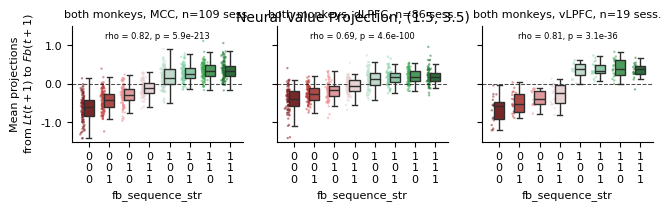

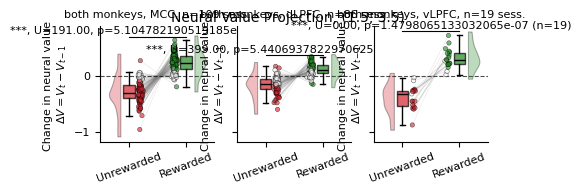

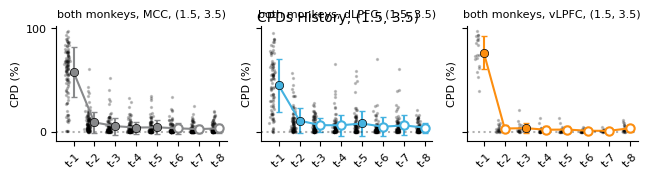

In [5]:
monkeys = 'both' # 'both', 'two'

n_perms = 500  # number of permutations for CPD analysis

time_interval = (1.5, 3.5)

# rename columns for plotting: V_T_... to V_t, dV_... to dV
behav_new['V_t'] = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']
behav_new['dV'] = behav_new[f'dV_{time_interval[0]}_{time_interval[1]}']

# for each monkey, session, subregion, fb_sequence, take a mean of these columns
behav_new_sess_avg_sequence = behav_new.copy().groupby(['monkey', 'session', 'subregion', 'fb_sequence'])['V_t'].mean().reset_index()

behav_new_sess_avg_fb = []
for (monkey, session, subregion), group in behav_new.groupby(['monkey', 'session', 'subregion']):
    U, pval = stats.mannwhitneyu(group.loc[group['feedback'] == 0, 'dV'], group.loc[group['feedback'] == 1, 'dV'], alternative='two-sided')
    for fb in group['feedback'].unique():
        behav_new_sess_avg_fb.append({
            'monkey': monkey,
            'session': session,
            'subregion': subregion,
            'feedback': fb,
            'V_t': group.loc[group['feedback'] == fb, 'V_t'].mean(),
            'V_t_p1': group.loc[group['feedback'] == fb, 'V_t_p1'].mean(),
            'dV': group.loc[group['feedback'] == fb, 'dV'].mean(),
            'U': U,
            'signif': pval < 0.05
        })
behav_new_sess_avg_fb = pd.DataFrame(behav_new_sess_avg_fb)
    

# calculate simple GLM weights for each session, subregion, monkey
weights_all = simple_glm_weights(behav_new)

# Main analysis with joblib parallelization
cpd_all = get_cpd_all(behav_new, n_perms)

# font = 8
plt.rcParams.update({'font.size': 8})
fig1, axs1 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)
fig2, axs2 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
fig6, axs6 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)

monkey = 'both monkeys'

for s, subregion in enumerate(behav_new['subregion'].unique()):
    behav_new_temp = behav_new.loc[behav_new['subregion'] == subregion]
    behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[behav_new_sess_avg_sequence['subregion'] == subregion]
    behav_new_sess_avg_feed_temp = behav_new_sess_avg_fb.loc[behav_new_sess_avg_fb['subregion'] == subregion]

    weights_all_temp = weights_all.loc[weights_all['subregion'] == subregion]
    cpd_all_temp = cpd_all.loc[cpd_all['subregion'] == subregion]
    null_temp = create_permutation_null(behav_new.loc[behav_new['subregion'] == subregion], n_perms=n_perms)

    ax = axs1[s]
    plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=True, ylim=[-1.5, 1.5], show_datapoints=True, showfliers=False, ax=ax)
    ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_sequence_temp["session"].unique())} sess.', fontsize=8)

    ax = axs2[s]
    create_r_style_plot(ax, behav_new_sess_avg_feed_temp, 'feedback', 'dV')
    ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_feed_temp["session"].unique())} sess.', fontsize=8)

    ax = axs6[s]
    plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax, show_data=True)
    ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

# save figure
fig1.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
fig2.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
fig6.suptitle(f'CPDs History, {time_interval}', fontsize=10)

plt.show()
plt.close('all')
